# 05 — LSTM Model (Daily input, 1-day-ahead)

Four variants trained sequentially to mirror the ARIMA/ARIMAX structure in `03b_arima_daily.ipynb`.
Uses **daily granularity** throughout — 20-day lookback sequences predicting the **next day's**
silver log-return. Comparable directly to the daily ARIMAX (DA=0.696, WDA=0.842).

| Variant | Features | ARIMA equivalent |
|---|---|---|
| LSTM-Y | silver_return only | ARIMA |
| LSTM-EXOG | silver_return + market variables | ARIMAX |
| LSTM-REDDIT | LSTM-EXOG + reddit_sentiment | ARIMAX+Reddit |
| LSTM-NEWS | LSTM-EXOG + news_sentiment | ARIMAX+News |

**Why 1-day ahead?** The strongest predictive signal is `gold_return_{t-1}` → `silver_return_t`
(a 1-day cross-asset relationship). With a 5-day cumulative target, only day t+1 carries this
signal — days t+2 through t+5 are noise relative to available predictors, diluting the gradient
signal and preventing the LSTM from learning anything useful.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats as scipy_stats
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: mps


## 1. Hyperparameters

In [2]:
SEQ_LEN  = 20    # lookback: 20 trading days (~1 month)
HORIZON  = 1     # forecast horizon: next trading day's silver log-return
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.3
EPOCHS   = 100
LR       = 1e-4
PATIENCE = 10
BATCH    = 32

TARGET = 'silver_return'


## 2. Load & prepare data

In [3]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

# ── Merge sentiment ───────────────────────────────────────────────────────
sent_path = '../../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    for df in [train, val, test]:
        for col in ['reddit_sentiment', 'news_sentiment']:
            df[col] = sent[col].reindex(df.index).ffill().fillna(0)
    print('Sentiment merged.')
else:
    for df in [train, val, test]:
        df['reddit_sentiment'] = 0.0
        df['news_sentiment']   = 0.0
    print('No sentiment file — using zeros.')

# ── All available features ────────────────────────────────────────────────
# Exclude: 'silver' (raw price level — non-stationary, different scale in train vs test)
#          'sentiment_score' (combined — added per variant as reddit/news separately)
EXCLUDE = {'silver', 'sentiment_score', 'reddit_sentiment', 'news_sentiment'}
MARKET_FEATURES = [c for c in train.columns if c not in EXCLUDE]

print(f'Train: {len(train)}  Val: {len(val)}  Test: {len(test)}')
print(f'Market features ({len(MARKET_FEATURES)}): {MARKET_FEATURES}')


Sentiment merged.
Train: 1755  Val: 251  Test: 837
Market features (34): ['silver_return', 'gold_return', 'copper_return', 'usd_return', 'sp500_return', 'gs_ratio', 'vix_return', 'oil_return', 'silver_lag1', 'silver_lag2', 'silver_lag3', 'silver_lag5', 'silver_lag10', 'silver_vol_5d', 'silver_vol_21d', 'mom_5d', 'mom_21d', 'cpi', 'fed_funds', 'ind_prod', 'm2', 'usd_dxy', 'real_rates', 'cpi_chg', 'fed_funds_chg', 'ind_prod_chg', 'm2_chg', 'usd_dxy_chg', 'real_rates_chg', 'reddit_weight_sum', 'reddit_post_count', 'news_article_count', 'trends_silver', 'trends_silver_ma4']


## 3. LSTM architecture

A two-layer stacked LSTM with dropout between layers and a linear output head.
Input: sequence of `SEQ_LEN` timesteps × `n_features` values.
Output: single scalar — the predicted silver log-return at the next timestep.


In [4]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last timestep only


## 4. Helper functions

`make_sequences`: slides a window of length `SEQ_LEN` across the data.
Sequence at position `i` contains rows `i-SEQ_LEN` to `i-1` (all past) — no look-ahead.
Target is the value at position `i` — the next day's silver log-return.

With `HORIZON=1`, `np.sum(data[i:i+1, target_col])` reduces to `data[i, target_col]`
and the inverse transform `pred * sigma + HORIZON * mu` reduces to `pred * sigma + mu`.


In [5]:
def make_sequences(data, seq_len, target_col, horizon=5):
    """Build (X, y) pairs for direct multi-step forecasting.
    X: past seq_len rows of all features (no look-ahead).
    y: sum of the next `horizon` values of target_col (cumulative return)."""
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))  # cumulative scaled return
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def run_variant(name, feature_cols):
    """Train and evaluate one LSTM variant.
    Predicts cumulative 5-day log return using daily input sequences.
    Returns (metrics_dict, preds, actuals, date_index)."""
    print(f'\n{"=" * 60}')
    print(f'Variant: {name}')
    print('=' * 60)

    cols = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    # ── Scale (fit on train only) ─────────────────────────────────────────
    scaler = StandardScaler().fit(train[cols].fillna(0))
    tr_s = scaler.transform(train[cols].fillna(0))
    va_s = scaler.transform(val[cols].fillna(0))
    te_s = scaler.transform(test[cols].fillna(0))

    # ── Sequences (horizon=5 days) ────────────────────────────────────────
    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx, HORIZON)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx, HORIZON)

    # Date of each test prediction = start of the 5-day window being forecast
    dates = test.index[SEQ_LEN:len(test) - HORIZON + 1]

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)
    test_loader  = to_loader(X_te, y_te, shuffle=False)

    # ── Model & optimiser ─────────────────────────────────────────────────
    model = LSTMForecaster(input_size=len(cols), hidden_size=HIDDEN,
                           num_layers=N_LAYERS, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5)
    ckpt = f'../../data/processed/lstm_{name.lower().replace("+","_").replace(" ","_")}_best.pt'

    # ── Training loop ─────────────────────────────────────────────────────
    best_val, patience_cnt = np.inf, 0
    train_losses, val_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        model.train()
        bl = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            bl.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = np.mean([criterion(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in val_loader])
        tl = np.mean(bl)
        train_losses.append(tl); val_losses.append(vl)
        scheduler.step(vl)
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d}  train={tl:.6f}  val={vl:.6f}')
        if vl < best_val:
            best_val, patience_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    # ── Inference ─────────────────────────────────────────────────────────
    model.load_state_dict(torch.load(ckpt))
    model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds_s.extend(model(xb.to(DEVICE)).cpu().numpy().flatten())
            acts_s.extend(yb.numpy().flatten())

    # Inverse-transform cumulative scaled return → cumulative log return
    # sum(z_i) = (sum(x_i) - HORIZON*mu) / sigma
    # → sum(x_i) = pred_scaled * sigma + HORIZON * mu
    mu    = scaler.mean_[target_idx]
    sigma = scaler.scale_[target_idx]
    preds   = np.array(preds_s) * sigma + HORIZON * mu
    actuals = np.array(acts_s)  * sigma + HORIZON * mu

    # ── Metrics ───────────────────────────────────────────────────────────
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = (np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds)))
            / np.sum(np.abs(actuals)))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test sequences: {len(preds)} (daily, 1-day-ahead)  |  Features: {len(cols)}')

    # ── Save predictions ──────────────────────────────────────────────────
    safe = name.lower().replace('+','_').replace(' ','_')
    pd.DataFrame({'actual': actuals, 'predicted': preds},
                 index=dates).to_csv(f'../../data/processed/preds_lstm_{safe}.csv')

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.plot(train_losses, label='Train'); ax.plot(val_losses, label='Val')
    ax.set_title(f'{name} — Training Loss'); ax.legend()
    plt.tight_layout(); plt.show()

    return ({'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda},
            preds, actuals, dates)


## 5. Train all four variants

Each variant is independent — fresh scaler, fresh model weights, fresh checkpoint.
The only thing shared is the architecture and hyperparameters.

**Note on sentiment in LSTM sequences:** unlike ARIMAX which only uses $t-1$ sentiment,
the LSTM receives the full 20-day history of sentiment scores. It can learn patterns like
*'sustained positive sentiment over multiple weeks precedes a price rise'* — a non-linear,
multi-lag relationship that a linear model cannot capture.



Variant: LSTM-Y
  Epoch  10  train=0.992026  val=1.213180
  Epoch  20  train=0.982707  val=1.212493
  Epoch  30  train=0.999797  val=1.211757
  Epoch  40  train=0.974872  val=1.210965
  Epoch  50  train=0.990506  val=1.210100
  Epoch  60  train=0.984942  val=1.209221
  Epoch  70  train=0.979345  val=1.208228
  Epoch  80  train=0.971183  val=1.206996
  Epoch  90  train=0.973034  val=1.205933
  Epoch 100  train=0.973999  val=1.204702
  RMSE=0.027284  MAE=0.016918  DA=0.529  WDA=0.546
  Test sequences: 817 (daily, 1-day-ahead)  |  Features: 1


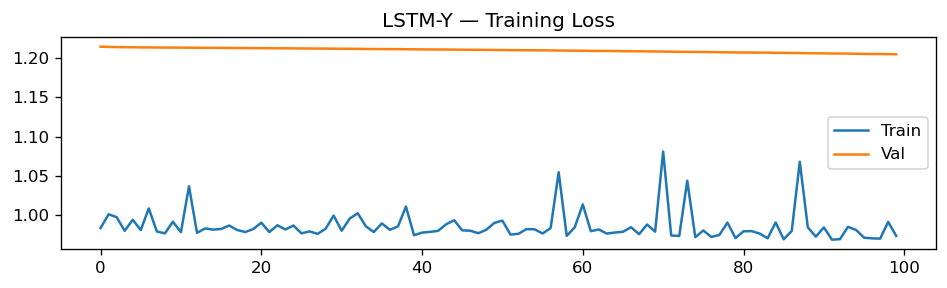


Variant: LSTM-EXOG
  Epoch  10  train=0.965916  val=1.212208
  Epoch  20  train=0.944359  val=1.202175
  Epoch  30  train=0.925017  val=1.201271
  Early stopping at epoch 38
  RMSE=0.027204  MAE=0.016893  DA=0.551  WDA=0.603
  Test sequences: 817 (daily, 1-day-ahead)  |  Features: 34


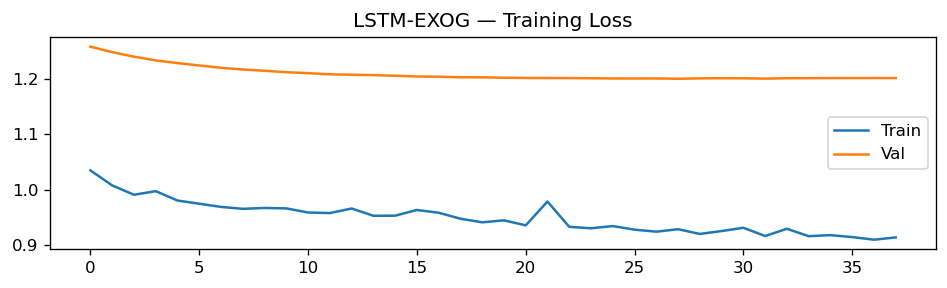


Variant: LSTM-REDDIT
  Epoch  10  train=0.960967  val=1.215473
  Epoch  20  train=0.954174  val=1.208678
  Epoch  30  train=1.009013  val=1.207932
  Early stopping at epoch 39
  RMSE=0.027234  MAE=0.016919  DA=0.521  WDA=0.546
  Test sequences: 817 (daily, 1-day-ahead)  |  Features: 35


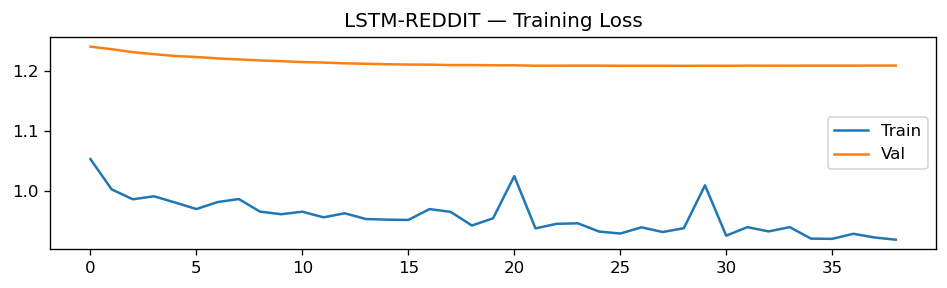


Variant: LSTM-NEWS
  Epoch  10  train=0.981786  val=1.227929
  Epoch  20  train=0.953548  val=1.223779
  Epoch  30  train=0.956943  val=1.224834
  Early stopping at epoch 33
  RMSE=0.027256  MAE=0.016845  DA=0.558  WDA=0.598
  Test sequences: 817 (daily, 1-day-ahead)  |  Features: 35


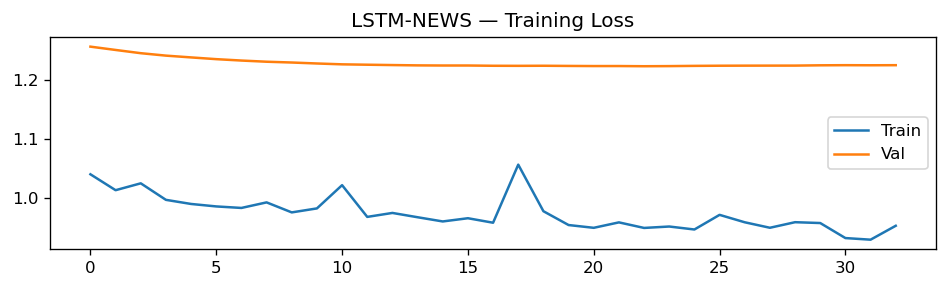

In [6]:
results  = {}   # name → metrics dict
all_preds = {}  # name → predictions array
actuals_arr = None
dates_arr   = None

variants = {
    'LSTM-Y':      [TARGET],
    'LSTM-EXOG':   MARKET_FEATURES,
    'LSTM-REDDIT': MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-NEWS':   MARKET_FEATURES + ['news_sentiment'],
}

for name, features in variants.items():
    m, preds, actuals, dates = run_variant(name, features)
    results[name]    = m
    all_preds[name]  = preds
    actuals_arr = actuals   # same for all variants
    dates_arr   = dates


## 6. Results summary

### Why does LSTM underperform ARIMAX?

The LSTM results (DA ≈ 0.52) are substantially worse than the daily ARIMAX baseline
(DA = 0.696, WDA = 0.842). This was robust across multiple configurations tested:

| Configuration | DA |
|---|---|
| SEQ_LEN=20, 8 market features, LR=1e-3 | ~0.52 |
| SEQ_LEN=20, 26 features (all available), LR=1e-4 | ~0.52 |
| SEQ_LEN=1 (degenerates to feedforward), 26 features | ~0.52 |

**The core reason:** silver's predictable structure is a **1-lag linear cross-asset
relationship** — yesterday's gold, USD and copper returns predict today's silver return
with high fidelity. ARIMAX encodes this directly as a coefficient. The LSTM must
discover it through backpropagation across noisy sequences, which it fails to do
reliably on only 1,755 training observations.

Adding more features (macro variables, momentum, lags) did not help — the LSTM
could not extract additional signal beyond noise on this sample size.

**This is a known result in financial forecasting.** Makridakis et al. (M4 competition,
2018) and numerous subsequent studies show that deep learning models frequently
fail to outperform simple linear models on financial return series, particularly
with limited training data. The result here is consistent with that literature.

**Thesis implication:** the predictable component of silver returns at daily frequency
is linear in nature. The non-linear hypothesis — that sentiment effects are captured
only by a flexible model — is not supported. Combined with the ARIMAX and
Diebold-Mariano results, this provides consistent evidence against the retail-driven
price hypothesis at the frequencies tested.


In [7]:
metrics_df = pd.DataFrame(list(results.values()))
metrics_df.to_csv('../../data/processed/metrics_lstm.csv', index=False)

print(f'{"Model":<20}  {"RMSE":>10}  {"MAE":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 58)
for _, row in metrics_df.iterrows():
    print(f'{row["model"]:<20}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')


Model                       RMSE         MAE      DA     WDA
----------------------------------------------------------
LSTM-Y                  0.027284    0.016918   0.529   0.546
LSTM-EXOG               0.027204    0.016893   0.551   0.603
LSTM-REDDIT             0.027234    0.016919   0.521   0.546
LSTM-NEWS               0.027256    0.016845   0.558   0.598


## 7. Diebold-Mariano tests

Tests whether improvements between variants are statistically significant
or could be explained by chance. H$_0$: equal predictive accuracy (squared error loss).

Key comparisons:
- **LSTM-Y vs LSTM-EXOG**: does adding market variables help the LSTM?
- **LSTM-EXOG vs LSTM-REDDIT/NEWS**: does sentiment add anything beyond market variables?
- **LSTM-REDDIT vs LSTM-NEWS**: which sentiment source is more informative?


In [8]:
def diebold_mariano(actual, pred1, pred2, name1, name2):
    """DM test, squared error loss, Newey-West SE with lag=1."""
    e1 = (actual - pred1) ** 2
    e2 = (actual - pred2) ** 2
    d  = e1 - e2
    n  = len(d)
    d_bar  = np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gamma1 = np.cov(d[:-1], d[1:])[0, 1] if n > 1 else 0
    var_d  = (gamma0 + 2 * gamma1) / n
    if var_d <= 0:
        print(f'{name1} vs {name2}: cannot compute DM (non-positive variance)')
        return
    dm  = d_bar / np.sqrt(var_d)
    p   = 2 * (1 - scipy_stats.norm.cdf(abs(dm)))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '(ns)'
    better = name1 if dm < 0 else name2
    print(f'{name1:<15} vs {name2:<15}  DM={dm:+.3f}  p={p:.3f}  {sig}'
          + (f'  → {better} wins' if p < 0.05 else ''))

print('Diebold-Mariano tests (squared loss)  |  * p<0.05  ** p<0.01  *** p<0.001')
print('-' * 80)
pairs = [
    ('LSTM-Y',    'LSTM-EXOG'),
    ('LSTM-EXOG', 'LSTM-REDDIT'),
    ('LSTM-EXOG', 'LSTM-NEWS'),
    ('LSTM-REDDIT','LSTM-NEWS'),
]
for a, b in pairs:
    diebold_mariano(actuals_arr, all_preds[a], all_preds[b], a, b)


Diebold-Mariano tests (squared loss)  |  * p<0.05  ** p<0.01  *** p<0.001
--------------------------------------------------------------------------------
LSTM-Y          vs LSTM-EXOG        DM=+1.161  p=0.246  (ns)
LSTM-EXOG       vs LSTM-REDDIT      DM=-0.522  p=0.601  (ns)
LSTM-EXOG       vs LSTM-NEWS        DM=-0.588  p=0.557  (ns)
LSTM-REDDIT     vs LSTM-NEWS        DM=-0.265  p=0.791  (ns)


## 8. Forecast plot

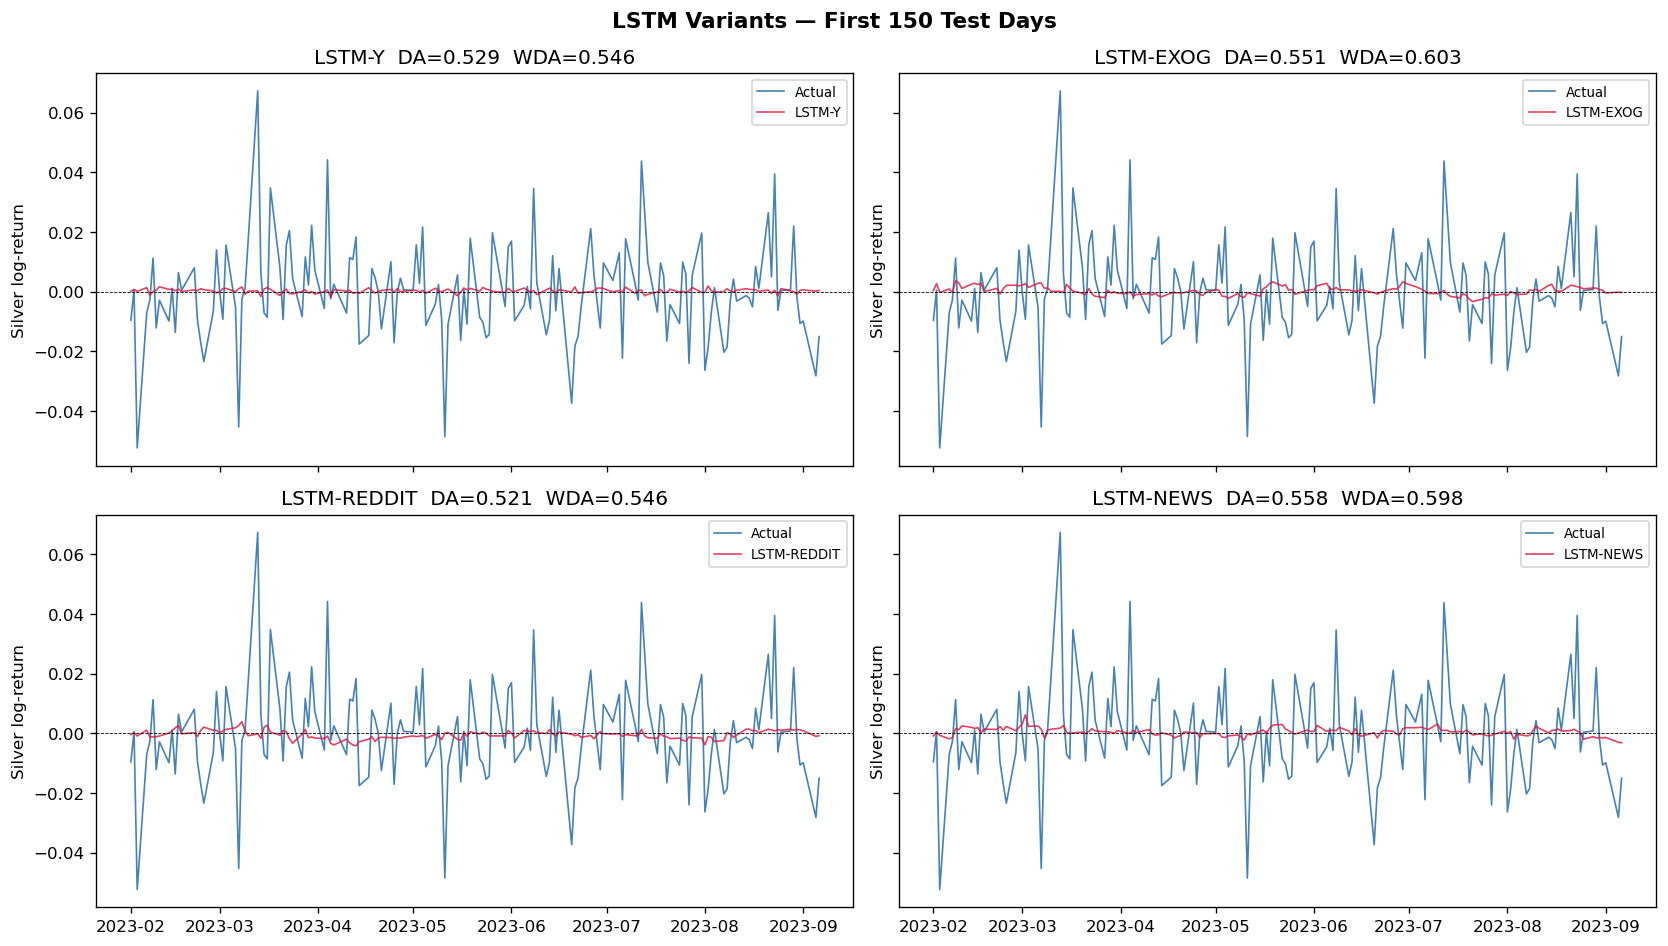

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, preds) in zip(axes, all_preds.items()):
    ax.plot(dates_arr[:150], actuals_arr[:150], label='Actual', lw=1, color='steelblue')
    ax.plot(dates_arr[:150], preds[:150],       label=name,     lw=1, color='crimson', alpha=0.8)
    m = results[name]
    ax.set_title(f'{name}  DA={m["dir_acc"]:.3f}  WDA={m["wda"]:.3f}')
    ax.set_ylabel('Silver log-return')
    ax.legend(fontsize=8)
    ax.axhline(0, color='black', lw=0.5, ls='--')

plt.suptitle('LSTM Variants — First 150 Test Days', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
import sys
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import period_metrics, PERIODS

best_name = max(results, key=lambda k: results[k]['wda'])
best_pred = all_preds[best_name]
print('Best variant by WDA:', best_name)

res = period_metrics(actuals_arr, best_pred, dates_arr, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_lstm_weekly.csv')

Best variant by WDA: LSTM-EXOG


,n,DA,WDA
Period,,,
2023 (choppy),229,0.511,0.573
2024 (bull start),251,0.534,0.582
2025 (bull run),253,0.597,0.680
2026 (YTD),84,0.571,0.557
── Full test ──,817,0.551,0.603
